In [1]:
# Si trabajas en Google Colab, revisa esta guía de ejecución de notebooks:
# https://docs.pytorch.org/tutorials/beginner/colab
# Activa la visualización de gráficos dentro del propio notebook.
%matplotlib inline

[Introduction](introyt1_tutorial.html) \|\|
[Tensors](tensors_deeper_tutorial.html) \|\|
[Autograd](autogradyt_tutorial.html) \|\| [Building
Models](modelsyt_tutorial.html) \|\| **TensorBoard Support** \|\|
[Training Models](trainingyt.html) \|\| [Model
Understanding](captumyt.html)

PyTorch TensorBoard Support
===========================

Follow along with the video below or on
[youtube](https://www.youtube.com/watch?v=6CEld3hZgqc).



In [3]:
# Carga y muestra el vídeo del tutorial dentro del notebook.
from IPython.display import display, HTML
html_code = """
<div style="margin-top:10px; margin-bottom:10px;">
  <iframe width="560" height="315" src="https://www.youtube.com/embed/6CEld3hZgqc" frameborder="0" allow="accelerometer; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>
</div>
"""
display(HTML(html_code))



Before You Start
----------------

To run this tutorial, you'll need to install PyTorch, TorchVision,
Matplotlib, and TensorBoard.

With `conda`:

``` {.sh}
conda install pytorch torchvision -c pytorch
conda install matplotlib tensorboard
```

With `pip`:

``` {.sh}
pip install torch torchvision matplotlib tensorboard
```

Once the dependencies are installed, restart this notebook in the Python
environment where you installed them.

Introduction
------------

In this notebook, we'll be training a variant of LeNet-5 against the
Fashion-MNIST dataset. Fashion-MNIST is a set of image tiles depicting
various garments, with ten class labels indicating the type of garment
depicted.


In [5]:
# ===============================
# Importaciones principales
# ===============================

# Núcleo de PyTorch para construir y entrenar modelos.
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Herramientas de TorchVision para datasets y transformaciones de imágenes.
import torchvision
import torchvision.transforms as transforms

# Librerías para visualización de imágenes en notebook.
import matplotlib.pyplot as plt
import numpy as np

# Escritor de TensorBoard: permite registrar imágenes, métricas y grafos.
from torch.utils.tensorboard import SummaryWriter

# Si usas un entorno con TensorFlow (ej. Colab), estas líneas pueden evitar
# problemas al guardar embeddings en el directorio de TensorBoard.
# import tensorflow as tf
# import tensorboard as tb
# tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

Showing Images in TensorBoard
=============================

Let's start by adding sample images from our dataset to TensorBoard:


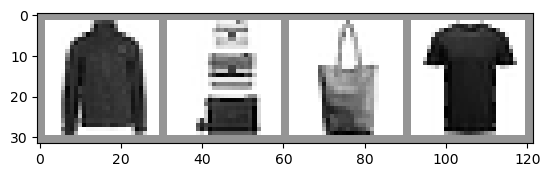

In [6]:
# ===========================================
# Preparación de datos para Fashion-MNIST
# ===========================================

# Transformación: imagen -> tensor y normalización a rango aproximado [-1, 1].
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# Descarga y carga del conjunto de entrenamiento.
training_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=True,
    transform=transform)

# Descarga y carga del conjunto de validación/prueba.
validation_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=False,
    transform=transform)

# DataLoader de entrenamiento: mezcla datos para mejorar el aprendizaje. 
# Lo suyo es hacer una partición estratificada para que ambos sets tengan la misma proporción de clases, pero aquí lo hacemos simple para el tutorial.
training_loader = torch.utils.data.DataLoader(training_set,
                                              batch_size=4,
                                              shuffle=True,
                                              num_workers=2)

# DataLoader de validación: sin mezcla para evaluación consistente.
validation_loader = torch.utils.data.DataLoader(validation_set,
                                                batch_size=4,
                                                shuffle=False,
                                                num_workers=2)

# Nombres de clases del dataset Fashion-MNIST.
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Función auxiliar para mostrar tensores de imagen en notebook.
def matplotlib_imshow(img, one_channel=False):
    # Si se pide un canal, promediamos canales para visualizar en escala de grises.
    if one_channel:
        img = img.mean(dim=0)
    # Desnormalizamos para visualizar correctamente.
    img = img / 2 + 0.5
    # Convierte img (normalmente un tensor de PyTorch) en un arreglo de NumPy y lo guarda en npimg. Esto suele hacerse cuando se quiere usar una imagen con herramientas que esperan NumPy, por ejemplo funciones de visualización con Matplotlib.
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        # Convierte de formato CHW (PyTorch) a HWC (Matplotlib).
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Extraemos un minibatch de 4 imágenes del loader de entrenamiento.
# Como el DataLoader se creó con batch_size=4, cada iteración devuelve un lote de 4 imágenes y sus etiquetas correspondientes.
dataiter = iter(training_loader)
images, labels = next(dataiter)

# Construimos una cuadrícula de imágenes para verla de forma compacta.
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

Above, we used TorchVision and Matplotlib to create a visual grid of a
minibatch of our input data. Below, we use the `add_image()` call on
`SummaryWriter` to log the image for consumption by TensorBoard, and we
also call `flush()` to make sure it's written to disk right away.


In [7]:
# Crea un escritor de TensorBoard con un directorio de logs específico.
# Creará un nuevo directorio "runs/fashion_mnist_experiment_1" donde se guardarán los datos para TensorBoard. Si el directorio ya existe, se agregarán nuevos datos sin sobrescribir los anteriores, lo que permite comparar diferentes ejecuciones.
writer = SummaryWriter('runs/fashion_mnist_experiment_1')

# Registra la cuadrícula de 4 imágenes en TensorBoard.
writer.add_image('Four Fashion-MNIST Images', img_grid)

# Fuerza escritura inmediata en disco para que TensorBoard lo vea al instante.
writer.flush()

# Para visualizarlo en terminal:
#   tensorboard --logdir=runs
# Luego abre: http://localhost:6006/

If you start TensorBoard at the command line and open it in a new
browser tab (usually at [localhost:6006](localhost:6006)), you should
see the image grid under the IMAGES tab.

Graphing Scalars to Visualize Training
======================================

TensorBoard is useful for tracking the progress and efficacy of your
training. Below, we'll run a training loop, track some metrics, and save
the data for TensorBoard's consumption.

Let's define a model to categorize our image tiles, and an optimizer and
loss function for training:


In [8]:
# ===========================================
# Definición del modelo (estilo LeNet)
# ===========================================
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Bloque convolucional 1: 1 canal de entrada -> 6 mapas de características.
        self.conv1 = nn.Conv2d(1, 6, 5)
        # MaxPooling 2x2 para reducir dimensión espacial.
        self.pool = nn.MaxPool2d(2, 2)
        # Bloque convolucional 2: 6 canales -> 16 mapas de características.
        self.conv2 = nn.Conv2d(6, 16, 5)
        # Capas totalmente conectadas para clasificación final.
        # IMPORTANTE ====> Antes de usar estas capas lineales, hay que aplanar la salida del bloque convolucional. 
        # Dado que el bloque convolucional produce 16 mapas de características de tamaño 4x4 (después de aplicar pooling),
        # el número total de características de entrada para la primera capa lineal es 16 * 4 * 4 = 256.
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        # Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        # Aplana para entrar a capas lineales. El tamaño de lote se mantiene dinámico con -1.
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # Salida en logits para usar con CrossEntropyLoss.
        x = self.fc3(x)
        return x
    

# Instanciamos red, función de pérdida y optimizador SGD.
net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

Now let's train a single epoch, and evaluate the training vs. validation
set losses every 1000 batches:


In [9]:
# Mostramos cuántos minibatches existen en validación.
# Esto se usa más abajo para calcular la media de la pérdida de validación.
print(len(validation_loader))

# Entrenamos 1 época (pasada completa por el conjunto de entrenamiento).
for epoch in range(1):
    # Acumula la pérdida de entrenamiento para sacar promedio cada 1000 batches.
    running_loss = 0.0

    # Recorremos el DataLoader de entrenamiento por minibatches.
    for i, data in enumerate(training_loader, 0):
        # 'data' viene como tupla: (inputs, labels).
        inputs, labels = data

        # Limpia gradientes anteriores para no acumularlos entre iteraciones.
        optimizer.zero_grad()

        # Forward: predicción del modelo para el batch actual.
        outputs = net(inputs)

        # Cálculo de pérdida comparando logits con etiquetas reales.
        loss = criterion(outputs, labels)

        # Backpropagation: calcula gradientes de todos los parámetros.
        loss.backward()

        # Actualización de parámetros según el optimizador (SGD).
        optimizer.step()

        # Sumamos la pérdida escalar del batch para estadísticas.
        """
        loss.item() devuelve un número de Python (float) con el valor escalar de la pérdida en ese batch.

        En otras palabras:

        - loss es un tensor (normalmente de 1 valor) que aún pertenece al grafo de PyTorch.
        - loss.item() extrae ese valor como número “normal”, útil para imprimir, acumular métricas (running_loss += ...) o registrar en TensorBoard.
        """
        running_loss += loss.item()

        # Cada 1000 minibatches hacemos evaluación en validación y logging.
        if i % 1000 == 999:
            print('Batch {}'.format(i + 1))

            # Acumulador para la pérdida de validación.
            running_vloss = 0.0
            
            # Pasamos a modo evaluación (desactiva dropout, ajusta batchnorm, etc.).
            net.train(False)

            # Recorremos todo validación para estimar pérdida media.
            for j, vdata in enumerate(validation_loader, 0):
                vinputs, vlabels = vdata
                voutputs = net(vinputs)
                vloss = criterion(voutputs, vlabels)
                running_vloss += vloss.item()
            
            # Volvemos a modo entrenamiento para continuar optimizando.
            net.train(True)
            
            # Promedio de entrenamiento (últimos 1000 batches).
            avg_loss = running_loss / 1000
            # Promedio de validación (todos los batches de validación).
            avg_vloss = running_vloss / len(validation_loader)
            
            # Registra ambas curvas en TensorBoard con un mismo eje global de pasos.
            writer.add_scalars('Training vs. Validation Loss',
                            { 'Training' : avg_loss, 'Validation' : avg_vloss },
                            epoch * len(training_loader) + i)

            # Reinicia acumulador para el siguiente tramo de 1000 batches.
            running_loss = 0.0

print('Finished Training')

# Fuerza el guardado de métricas en disco para verlas inmediatamente en TensorBoard.
writer.flush()

2500
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Finished Training


Switch to your open TensorBoard and have a look at the SCALARS tab.

Visualizing Your Model
======================

TensorBoard can also be used to examine the data flow within your model.
To do this, call the `add_graph()` method with a model and sample input:


In [10]:
# Toma un minibatch de ejemplo para trazar el grafo del modelo.
dataiter = iter(training_loader)
images, labels = next(dataiter)

# Registra el grafo computacional al pasar 'images' por la red.
writer.add_graph(net, images)

# Fuerza escritura inmediata de este artefacto.
writer.flush()

When you switch over to TensorBoard, you should see a GRAPHS tab.
Double-click the "NET" node to see the layers and data flow within your
model.

Visualizing Your Dataset with Embeddings
========================================

The 28-by-28 image tiles we're using can be modeled as 784-dimensional
vectors (28 \* 28 = 784). It can be instructive to project this to a
lower-dimensional representation. The `add_embedding()` method will
project a set of data onto the three dimensions with highest variance,
and display them as an interactive 3D chart. The `add_embedding()`
method does this automatically by projecting to the three dimensions
with highest variance.

Below, we'll take a sample of our data, and generate such an embedding:


In [11]:
# Selecciona n muestras aleatorias (imágenes y etiquetas) manteniendo alineación.
def select_n_random(data, labels, n=100):
    assert len(data) == len(labels)

    perm = torch.randperm(len(data))
    return data[perm][:n], labels[perm][:n]

# Extraemos un subconjunto aleatorio del dataset de entrenamiento.
images, labels = select_n_random(training_set.data, training_set.targets)

# Convertimos índices de clase a nombres legibles para TensorBoard.
class_labels = [classes[label] for label in labels]

# Aplanamos cada imagen 28x28 a vector de 784 características.
features = images.view(-1, 28 * 28)

# Registra embedding + metadatos + miniaturas de imagen.
writer.add_embedding(features,
                    metadata=class_labels,
                    label_img=images.unsqueeze(1))

# Escribe y cierra el writer al terminar.
writer.flush()
writer.close()

Now if you switch to TensorBoard and select the PROJECTOR tab, you
should see a 3D representation of the projection. You can rotate and
zoom the model. Examine it at large and small scales, and see whether
you can spot patterns in the projected data and the clustering of
labels.

For better visibility, it's recommended to:

-   Select "label" from the "Color by" drop-down on the left.
-   Toggle the Night Mode icon along the top to place the light-colored
    images on a dark background.

Other Resources
===============

For more information, have a look at:

-   PyTorch documentation on
    [torch.utils.tensorboard.SummaryWriter](https://pytorch.org/docs/stable/tensorboard.html?highlight=summarywriter)
-   Tensorboard tutorial content in the [PyTorch.org
    Tutorials](https://pytorch.org/tutorials/)
-   For more information about TensorBoard, see the [TensorBoard
    documentation](https://www.tensorflow.org/tensorboard)
